In [1]:
from keras.datasets import mnist
from keras.utils import to_categorical
from keras import layers,models,regularizers
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
(train_x,train_y),(test_x,test_y) = mnist.load_data()

In [3]:
print("train_x.shape : ",train_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (60000, 28, 28)
test_x.shape :  (10000, 28, 28)


In [4]:
train_x = train_x.reshape((train_x.shape[0],28*28)).astype('float32') / 255
test_x = test_x.reshape((10000,28*28)).astype('float32') / 255

# train_x = train_x.astype('float32') / 255
# test_x = test_x.astype('float32') / 255

train_y = to_categorical(train_y)
test_y = to_categorical(test_y)

In [5]:
validation_x = train_x[50000:60000]
validation_y = train_y[50000:60000]

train_x = train_x[:50000]
train_y = train_y[:50000]

print("train_x.shape : ",train_x.shape)
print("validation_x.shape : ",validation_x.shape)
print("test_x.shape : ",test_x.shape)

train_x.shape :  (50000, 784)
validation_x.shape :  (10000, 784)
test_x.shape :  (10000, 784)


In [6]:
def buildModel(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [7]:
def buildModelRegulalize(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dense(neuronNum , kernel_regularizer=regularizers.l2(0.001) , activation='relu') ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [8]:
def buildModelDropout(neuronNum,train_x) :
    model = models.Sequential([
        layers.Dense(neuronNum , activation='relu' , input_shape=(train_x.shape[1],)) ,
        layers.Dropout(0.5) ,
        layers.Dense(neuronNum , activation='relu') ,
        layers.Dropout(0.5) ,
        layers.Dense(10 , activation='softmax')
    ])
    model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [9]:
history_smaller = buildModel(32, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50


/Users/ponlawatchangto/Documents/Mylearning/4312/.venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 922us/step - accuracy: 0.8273 - loss: 0.6295 - val_accuracy: 0.9212 - val_loss: 0.2896
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 688us/step - accuracy: 0.9203 - loss: 0.2795 - val_accuracy: 0.9308 - val_loss: 0.2430
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 641us/step - accuracy: 0.9343 - loss: 0.2255 - val_accuracy: 0.9395 - val_loss: 0.2114
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step - accuracy: 0.9439 - loss: 0.1940 - val_accuracy: 0.9455 - val_loss: 0.1880
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 619us/step - accuracy: 0.9494 - loss: 0.1724 - val_accuracy: 0.9521 - val_loss: 0.1665
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 629us/step - accuracy: 0.9538 - loss: 0.1564 - val_accuracy: 0.9537 - val_loss: 0.1626
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step - accuracy: 0.9583 - loss: 0.1442 - val_accuracy: 0.9552 - val_loss: 0.1512
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 618us/step - accuracy: 0.9614 - loss: 0.1336 - val_accurac

In [10]:
history_original = buildModel(64, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8682 - loss: 0.4941 - val_accuracy: 0.9168 - val_loss: 0.2860
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - accuracy: 0.9313 - loss: 0.2343 - val_accuracy: 0.9432 - val_loss: 0.1997
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step - accuracy: 0.9486 - loss: 0.1753 - val_accuracy: 0.9441 - val_loss: 0.1852
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.9575 - loss: 0.1413 - val_accuracy: 0.9587 - val_loss: 0.1435
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - accuracy: 0.9650 - loss: 0.1186 - val_accuracy: 0.9604 - val_loss: 0.1360
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 824us/step - accuracy: 0.9702 - loss: 0.1017 - val_accuracy: 0.9683 - val_loss: 0.1090
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 871us/step - accuracy: 0.9739 - loss: 0.0877 - val_accuracy: 0.9613 - val_loss: 0.1333
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - accuracy: 0.9768 - loss: 0.0775 - va

In [11]:
history_larger = buildModel(512, train_x).fit(train_x, train_y, epochs=50, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9002 - loss: 0.3257 - val_accuracy: 0.9551 - val_loss: 0.1475
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9654 - loss: 0.1119 - val_accuracy: 0.9694 - val_loss: 0.1008
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9774 - loss: 0.0714 - val_accuracy: 0.9770 - val_loss: 0.0769
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9845 - loss: 0.0494 - val_accuracy: 0.9707 - val_loss: 0.0969
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9894 - loss: 0.0338 - val_accuracy: 0.9785 - val_loss: 0.0750
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9918 - loss: 0.0241 - val_accuracy: 0.9773 - val_loss: 0.0840
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9945 - loss: 0.0178 - val_accuracy: 0.9796 - val_loss: 0.0767
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9960 - loss: 0.0127 - val_accuracy: 0.

In [12]:
def plotLoss(history,name) :
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.plot(epochs,loss,'r',label='Training loss')
    plt.plot(epochs,val_loss,'b',label='Validation loss')
    plt.title('Training and Validation Loss '+ name)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [13]:
def plotAcc(history,name) :
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1 , len(accuracy) + 1)
    plt.plot(epochs,accuracy,'r',label='Training Accuracy')
    plt.plot(epochs,val_accuracy,'b',label='Validation Accuracy')
    plt.title('Training and Validation Accuracy ' + name)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

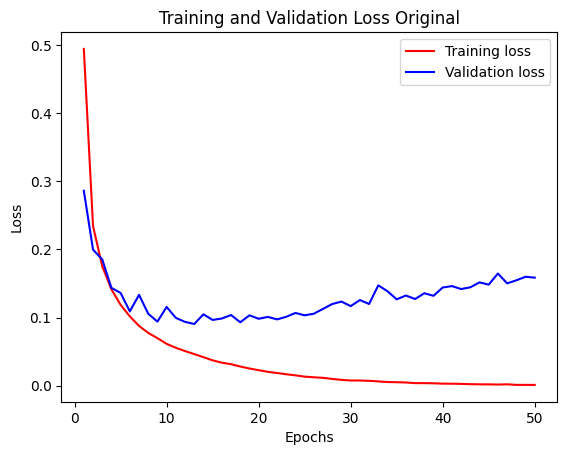

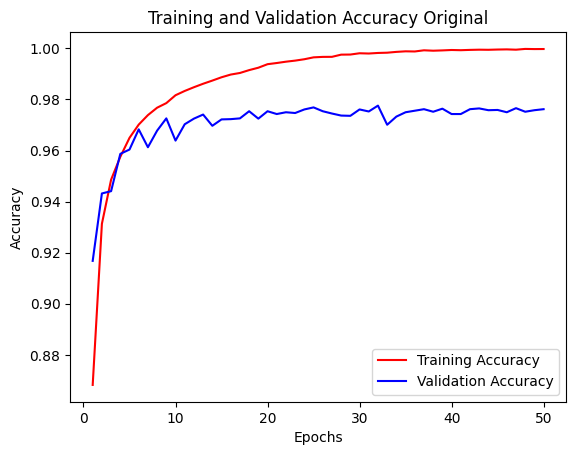

In [14]:
plotLoss(history_original,"Original")
plotAcc(history_original,"Original")

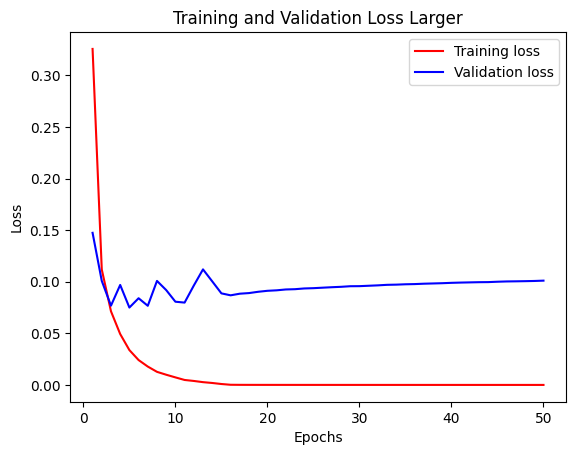

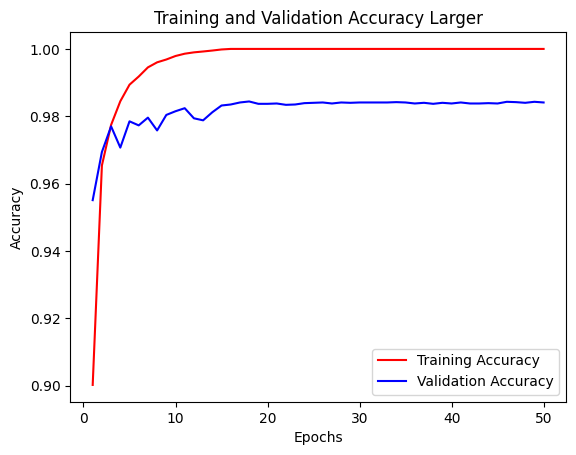

In [15]:
plotLoss(history_larger,"Larger")
plotAcc(history_larger,"Larger")

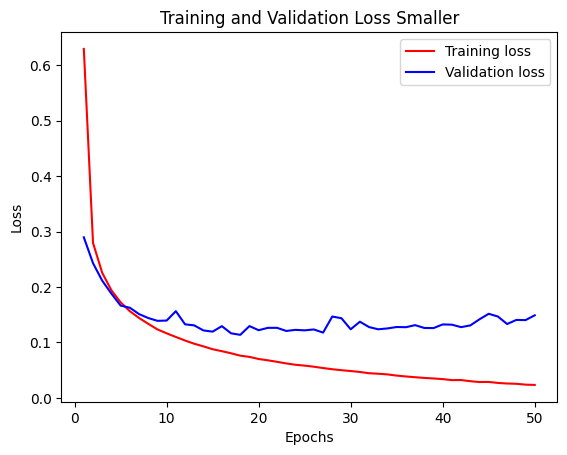

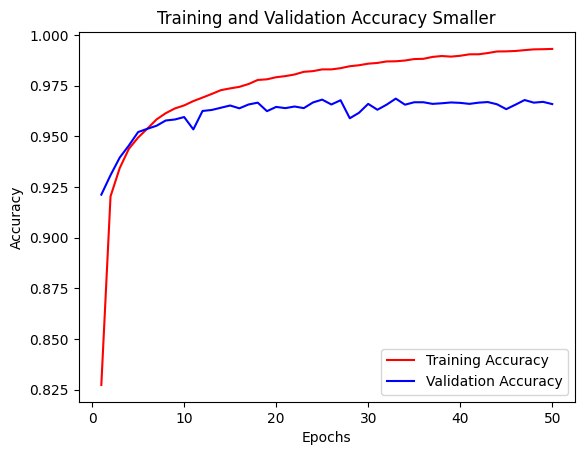

In [16]:
plotLoss(history_smaller,"Smaller")
plotAcc(history_smaller,"Smaller")

In [17]:
history_Dropout = buildModelDropout(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6449 - loss: 1.0891 - val_accuracy: 0.9082 - val_loss: 0.3464
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step - accuracy: 0.8318 - loss: 0.5753 - val_accuracy: 0.9276 - val_loss: 0.2578
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step - accuracy: 0.8671 - loss: 0.4695 - val_accuracy: 0.9354 - val_loss: 0.2251
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 941us/step - accuracy: 0.8812 - loss: 0.4200 - val_accuracy: 0.9447 - val_loss: 0.1993
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.8902 - loss: 0.3910 - val_accuracy: 0.9469 - val_loss: 0.1983
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 966us/step - accuracy: 0.8977 - loss: 0.3669 - val_accuracy: 0.9523 - val_loss: 0.1791
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.9028 - loss: 0.3465 - val_accuracy: 0.9516 - val_loss: 0.1737
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.9082 - loss: 0.3325 - va

In [18]:
history_Regularized = buildModelRegulalize(64 , train_x).fit(train_x,train_y,epochs=50,batch_size=256,validation_data=(validation_x,validation_y))

Epoch 1/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8668 - loss: 0.6584 - val_accuracy: 0.9217 - val_loss: 0.4153
Epoch 2/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.9310 - loss: 0.3756 - val_accuracy: 0.9403 - val_loss: 0.3421
Epoch 3/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - accuracy: 0.9452 - loss: 0.3179 - val_accuracy: 0.9551 - val_loss: 0.2840
Epoch 4/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.9526 - loss: 0.2814 - val_accuracy: 0.9560 - val_loss: 0.2732
Epoch 5/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 826us/step - accuracy: 0.9572 - loss: 0.2576 - val_accuracy: 0.9563 - val_loss: 0.2572
Epoch 6/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 820us/step - accuracy: 0.9621 - loss: 0.2365 - val_accuracy: 0.9617 - val_loss: 0.2407
Epoch 7/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.9649 - loss: 0.2208 - val_accuracy: 0.9639 - val_loss: 0.2264
Epoch 8/50
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - accuracy: 0.9673 - loss: 0.2084 - va

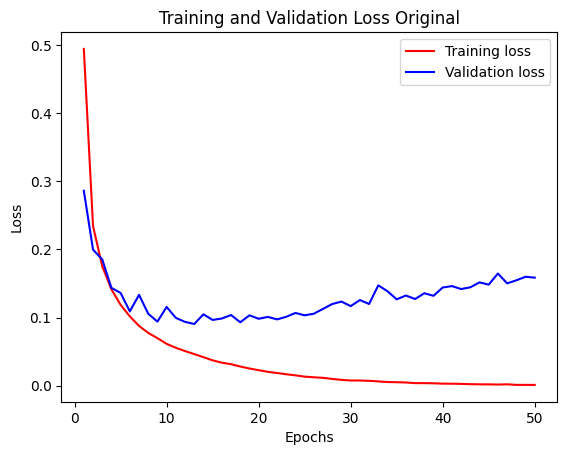

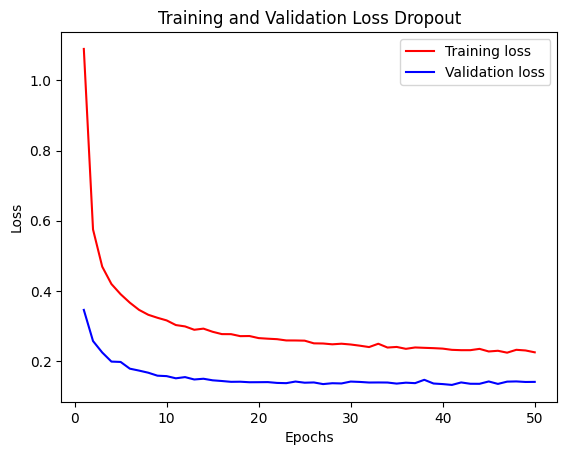

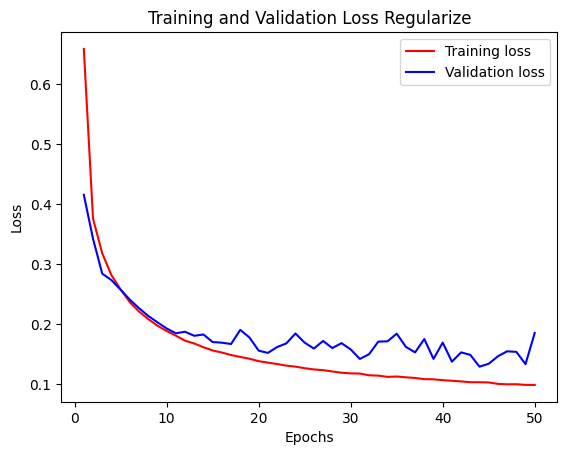

In [19]:
plotLoss(history_original,'Original')
plotLoss(history_Dropout,'Dropout')
plotLoss(history_Regularized,'Regularize')

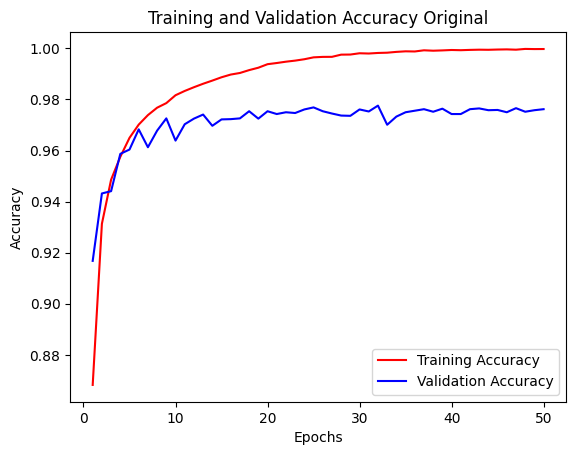

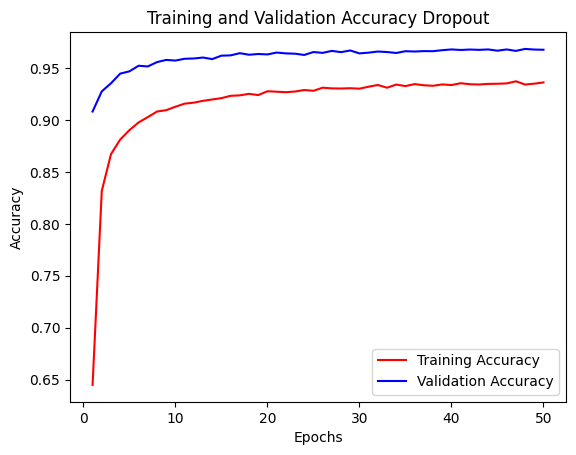

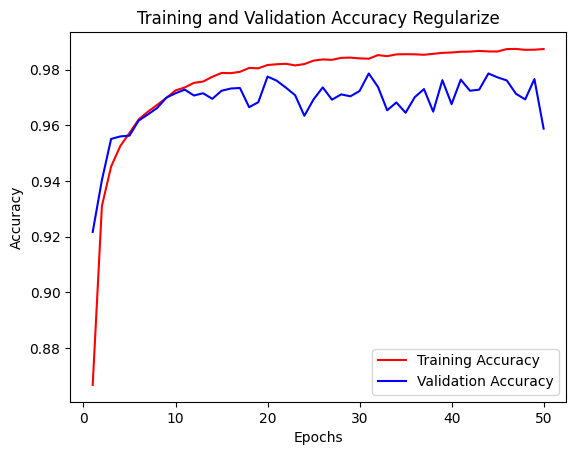

In [20]:
plotAcc(history_original,'Original')
plotAcc(history_Dropout,'Dropout')
plotAcc(history_Regularized,'Regularize')

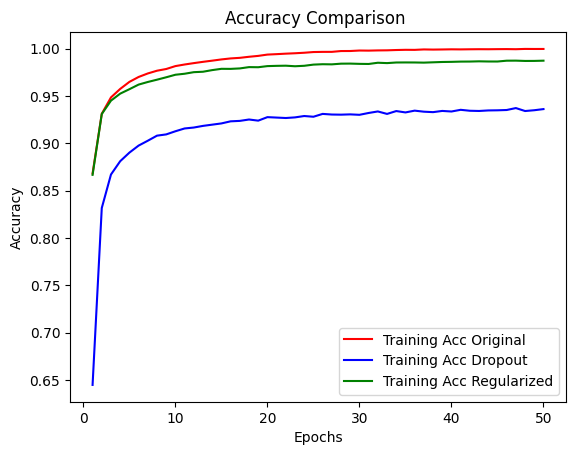

In [21]:
acc_ori = history_original.history['accuracy']
acc_DropOut = history_Dropout.history['accuracy']
acc_Regularized = history_Regularized.history['accuracy']
epochs = range(1,len(acc_ori)+1)
plt.plot(epochs,acc_ori,'r',label='Training Acc Original')
plt.plot(epochs,acc_DropOut,'b',label='Training Acc Dropout')
plt.plot(epochs,acc_Regularized,'g',label='Training Acc Regularized')
plt.title('Accuracy Comparison ')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

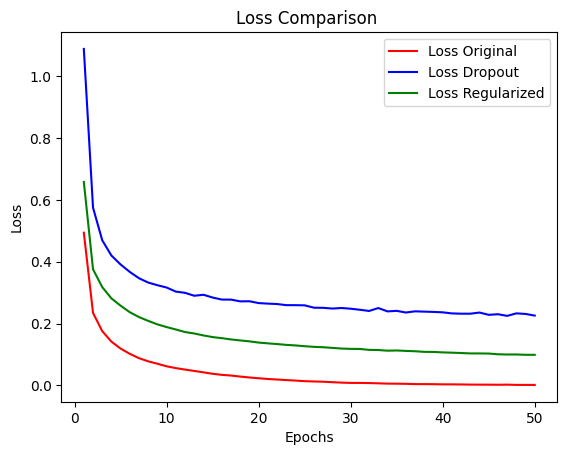

In [22]:
loss_ori = history_original.history['loss']
loss_DropOut = history_Dropout.history['loss']
loss_Regularized = history_Regularized.history['loss']
epochs = range(1,len(loss_ori)+1)
plt.plot(epochs,loss_ori,'r',label='Loss Original')
plt.plot(epochs,loss_DropOut,'b',label='Loss Dropout')
plt.plot(epochs,loss_Regularized,'g',label='Loss Regularized')
plt.title('Loss Comparison ')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

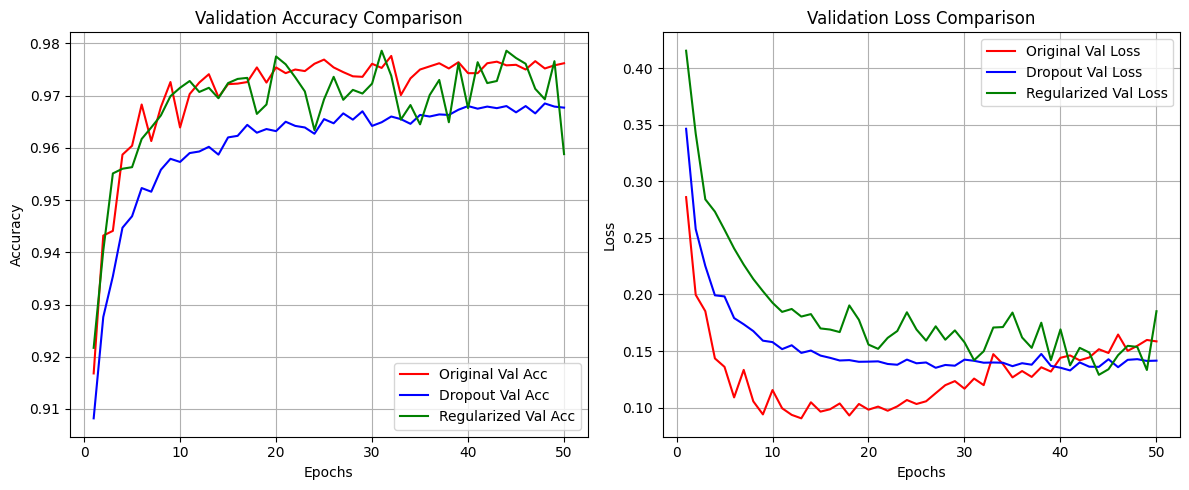

In [23]:
val_acc_ori = history_original.history['val_accuracy']
val_acc_drop = history_Dropout.history['val_accuracy']
val_acc_reg = history_Regularized.history['val_accuracy']

val_loss_ori = history_original.history['val_loss']
val_loss_drop = history_Dropout.history['val_loss']
val_loss_reg = history_Regularized.history['val_loss']

epochs = range(1, len(val_acc_ori) + 1)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs, val_acc_ori, 'r', label='Original Val Acc')
plt.plot(epochs, val_acc_drop, 'b', label='Dropout Val Acc')
plt.plot(epochs, val_acc_reg, 'g', label='Regularized Val Acc')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_loss_ori, 'r', label='Original Val Loss')
plt.plot(epochs, val_loss_drop, 'b', label='Dropout Val Loss')
plt.plot(epochs, val_loss_reg, 'g', label='Regularized Val Loss')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [24]:
history_original = buildModel(64, train_x).fit(train_x, train_y, epochs=11, batch_size=256, validation_data=(validation_x, validation_y))

Epoch 1/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8652 - loss: 0.4933 - val_accuracy: 0.9298 - val_loss: 0.2420
Epoch 2/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 896us/step - accuracy: 0.9350 - loss: 0.2269 - val_accuracy: 0.9422 - val_loss: 0.1975
Epoch 3/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 888us/step - accuracy: 0.9503 - loss: 0.1724 - val_accuracy: 0.9559 - val_loss: 0.1580
Epoch 4/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 821us/step - accuracy: 0.9587 - loss: 0.1406 - val_accuracy: 0.9598 - val_loss: 0.1384
Epoch 5/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 876us/step - accuracy: 0.9658 - loss: 0.1168 - val_accuracy: 0.9548 - val_loss: 0.1590
Epoch 6/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 914us/step - accuracy: 0.9700 - loss: 0.1001 - val_accuracy: 0.9673 - val_loss: 0.1170
Epoch 7/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - accuracy: 0.9741 - loss: 0.0879 - val_accuracy: 0.9701 - val_loss: 0.1008
Epoch 8/11
196/196 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.9771 - loss: 0.0778 - va

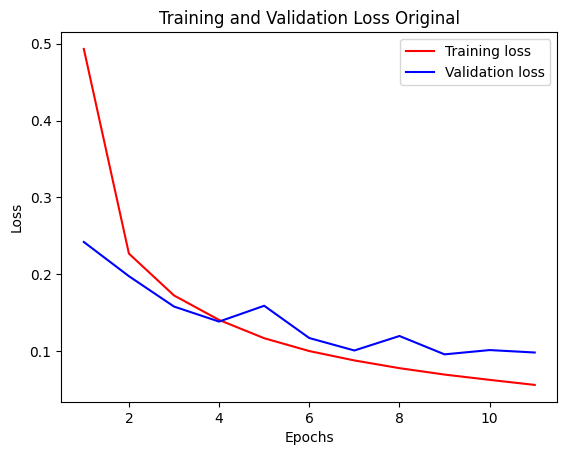

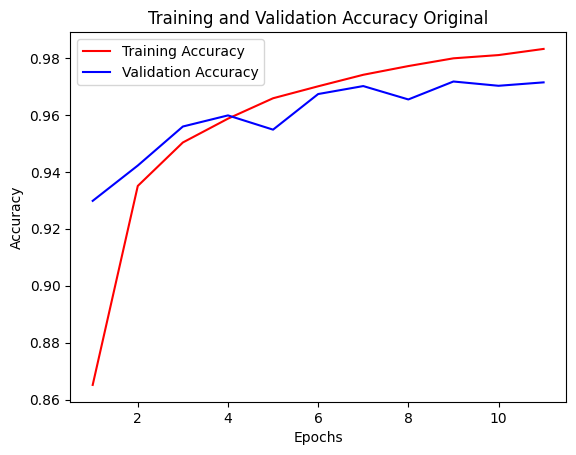

In [25]:
plotLoss(history_original,"Original")
plotAcc(history_original,"Original")

In [26]:
loss_ori , acc_ori = history_original.model.evaluate(test_x,test_y)
print(f"Loss : {loss_ori} , Acc : {acc_ori}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - accuracy: 0.9723 - loss: 0.0960
Loss : 0.09602056443691254 , Acc : 0.9722999930381775


In [27]:
loss_Large , acc_Large = history_larger.model.evaluate(test_x,test_y)
print(f"Loss : {loss_Large} , Acc : {acc_Large}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step - accuracy: 0.9851 - loss: 0.0868
Loss : 0.08684014528989792 , Acc : 0.9850999712944031


In [28]:
loss_small , acc_small = history_smaller.model.evaluate(test_x,test_y)
print(f"Loss : {loss_small} , Acc : {acc_small}")

  1/313 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9375 - loss: 0.2498

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step - accuracy: 0.9669 - loss: 0.1414
Loss : 0.1414371281862259 , Acc : 0.9668999910354614


In [29]:
loss_dropout , acc_dropout = history_Dropout.model.evaluate(test_x,test_y)
print(f"Loss : {loss_dropout} , Acc : {acc_dropout}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 295us/step - accuracy: 0.9642 - loss: 0.1492
Loss : 0.1491898149251938 , Acc : 0.9642000198364258


In [30]:
loss_Regularized , acc_Regularized = history_Regularized.model.evaluate(test_x,test_y)
print(f"Loss : {loss_Regularized} , Acc : {acc_Regularized}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 340us/step - accuracy: 0.9596 - loss: 0.1837
Loss : 0.18373943865299225 , Acc : 0.9595999717712402


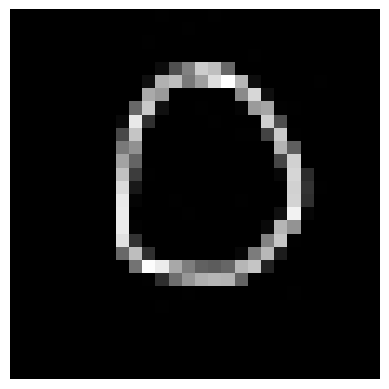

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
ผลการทำนาย: เลข 0
ความมั่นใจ: 61.67%


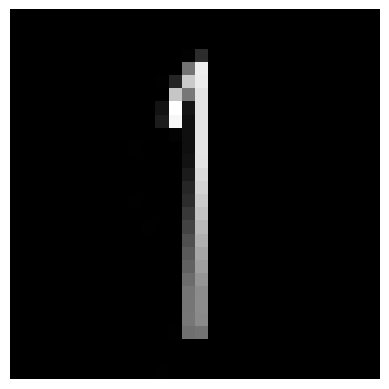

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
ผลการทำนาย: เลข 1
ความมั่นใจ: 94.76%


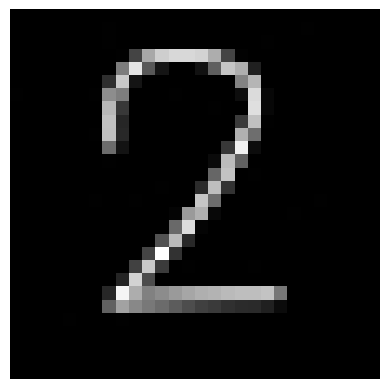

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 2
ความมั่นใจ: 79.59%


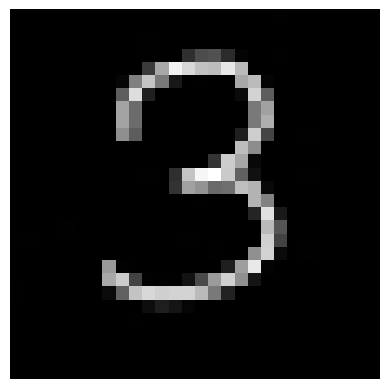

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 3
ความมั่นใจ: 90.74%


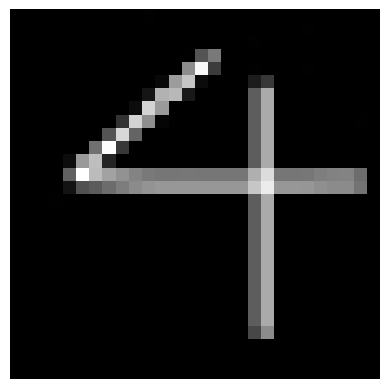

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 5
ความมั่นใจ: 31.46%


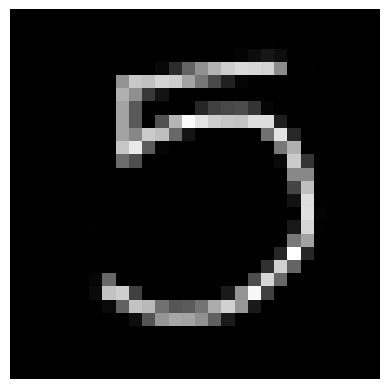

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 0
ความมั่นใจ: 58.11%


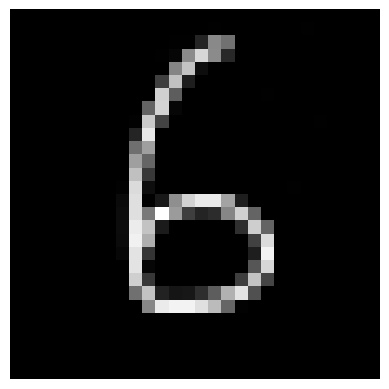

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 6
ความมั่นใจ: 94.70%


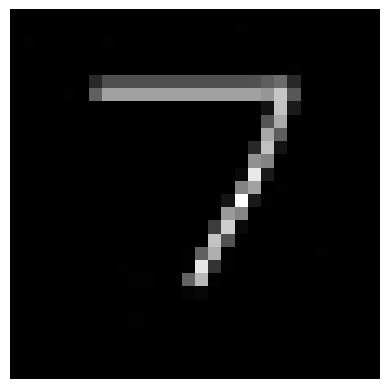

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
ผลการทำนาย: เลข 7
ความมั่นใจ: 50.49%


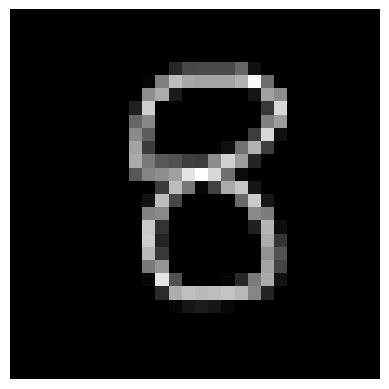

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
ผลการทำนาย: เลข 8
ความมั่นใจ: 47.15%


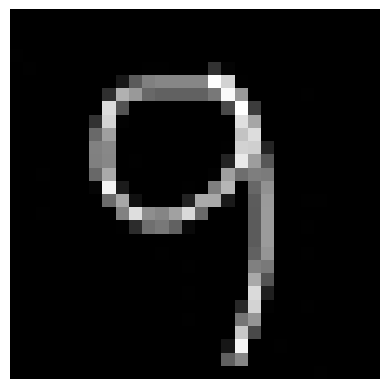

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
ผลการทำนาย: เลข 9
ความมั่นใจ: 97.52%


In [31]:
for i in range(0,10) :
    filename = f"test{i}.jpg"
    img = load_img(filename,color_mode='grayscale',target_size=(28,28))

    img_array = img_to_array(img)
    img_array = 255.0 - img_array

    img_array = img_array.reshape((1,28*28)).astype('float32')/255.0

    plt.imshow(img_array.reshape(28,28) , cmap='gray')
    plt.axis('off')
    plt.show()

    prediction = history_original.model.predict(img_array)
    predicted_digit = np.argmax(prediction)

    print(f"ผลการทำนาย: เลข {predicted_digit}")
    print(f"ความมั่นใจ: {prediction[0][predicted_digit] * 100:.2f}%")